In [1]:
import pandas as pd

In [2]:
df=pd.read_csv('/content/drive/MyDrive/Healthcare Project/cleaned_data.csv')

In [3]:
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hypertension,Diabetes,Alcoholism,Handicap,SMS_received,No-show,WaitingDays,AppointmentDayName
0,2.987250e+13,5642903,0,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,62,JARDIM DA PENHA,0,1,0,0,0,0,0,0,Friday
1,5.589978e+14,5642503,1,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0,0,0,0,0,0,0,Friday
2,4.262962e+12,5642549,0,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,62,MATA DA PRAIA,0,0,0,0,0,0,0,0,Friday
3,8.679512e+11,5642828,0,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00,8,PONTAL DE CAMBURI,0,0,0,0,0,0,0,0,Friday
4,8.841186e+12,5642494,0,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,1,1,0,0,0,0,0,Friday


In [4]:
feature_cols = ['Gender', 'Age', 'Scholarship', 'Hypertension', 'Diabetes',
                'Alcoholism', 'Handicap', 'SMS_received', 'WaitingDays', 'AppointmentDayName']

In [5]:
X=pd.get_dummies(df[feature_cols],columns=['AppointmentDayName'], drop_first=True)
y=df['No-show']

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model Training

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

model=RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=42)

print("Training the production Random Forest model... Please wait.")
model.fit(X_train, y_train)
print("Model training complete!")

Training the production Random Forest model... Please wait.
Model training complete!


# Classification Report

In [8]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Generate definitive predictions and probability metrics on unseen data
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("FINAL PIPELINE PRODUCTION PERFORMANCE")

# Primary technical classification breakdown
print(classification_report(y_test, y_pred))

# Confusion Matrix analysis
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(f"  True Positives (Caught No-Shows): {cm[1, 1]}")
print(f"  False Positives (False Alarms):  {cm[0, 1]}")
print(f"  False Negatives (Correct Shows):   {cm[0, 0]}")
print(f"  True Negatives (Missed No-Shows): {cm[1, 0]}")

# Overall model discriminative power calculation
print(f"\nFinal ROC-AUC Performance Score: {roc_auc_score(y_test, y_prob):.4f}")


FINAL PIPELINE PRODUCTION PERFORMANCE
              precision    recall  f1-score   support

           0       0.92      0.53      0.67     17621
           1       0.31      0.81      0.44      4484

    accuracy                           0.59     22105
   macro avg       0.61      0.67      0.56     22105
weighted avg       0.79      0.59      0.63     22105

Confusion Matrix:
  True Positives (Caught No-Shows): 3654
  False Positives (False Alarms):  8294
  True Negatives (Correct Shows):   9327
  False Negatives (Missed No-Shows): 830

Final ROC-AUC Performance Score: 0.7263


In [9]:
model.score(X_test,y_test)

0.5872427052703009

In [10]:
from sklearn.model_selection import cross_val_score

cvs=cross_val_score(model,X,y)

cvs.mean()

np.float64(0.586323080634713)

# Hyper parameter Tuning

In [11]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],         # Test forest sizes (more trees vs baseline)
    'max_depth': [8, 12, 16],           # Test tree heights (shallower vs deeper)
    'min_samples_split': [5, 10]        # Prevent overfitting to single patients
}

# Initialize a base model with our vital minority-class penalty setting intact
base_rf = RandomForestClassifier(class_weight='balanced', random_state=42)

# scoring='roc_auc' ensures Python evaluates models based on overall balance, NOT plain accuracy
grid_search = GridSearchCV(
    estimator=base_rf,
    param_grid=param_grid,
    cv=3,                               # 3-fold cross-validation per combination
    scoring='roc_auc',
    n_jobs=-1,                          # Use all available CPU processor cores for speed
    verbose=2                           # Prints out real-time logging progress
)

print("Starting Grid Search... This might take 1-3 minutes as it tests multiple models.")
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

print("GRID SEARCH TUNING RESULTS COMPLETE")
print(f"Optimal Hyperparameter Settings Discovered: {grid_search.best_params_}")

# Run final evaluation on unseen data using our optimized engine
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("\n--- FINAL OPTIMIZED MODEL PERFORMANCE ---")
print(classification_report(y_test, y_pred))
print(f"Optimized ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

Starting Grid Search... This might take 1-3 minutes as it tests multiple models.
Fitting 3 folds for each of 12 candidates, totalling 36 fits

GRID SEARCH TUNING RESULTS COMPLETE
Optimal Hyperparameter Settings Discovered: {'max_depth': 12, 'min_samples_split': 10, 'n_estimators': 200}

--- FINAL OPTIMIZED MODEL PERFORMANCE ---
              precision    recall  f1-score   support

           0       0.91      0.56      0.69     17621
           1       0.31      0.78      0.44      4484

    accuracy                           0.60     22105
   macro avg       0.61      0.67      0.57     22105
weighted avg       0.79      0.60      0.64     22105

Optimized ROC-AUC Score: 0.7273


# Threshold Optimization (Controlling the Balance)

In [12]:
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report

# Assuming 'best_model' from the Grid Search is already trained and X_test is ready
# We extract the raw continuous probability scores instead of hard 0s or 1s
y_probabilities = best_model.predict_proba(X_test)[:, 1]

# We will test three strategic business cutoffs
thresholds = [0.40, 0.50, 0.60]

for t in thresholds:
    print("\n" + "="*50)
    print(f"BUSINESS DECISION THRESHOLD SET TO: {t*100}%")
    print("="*50)

    # If the probability is greater than t, map to 1 (No-Show), else 0
    custom_preds = np.where(y_probabilities >= t, 1, 0)

    print(classification_report(y_test, custom_preds))


BUSINESS DECISION THRESHOLD SET TO: 40.0%
              precision    recall  f1-score   support

           0       0.95      0.43      0.59     17621
           1       0.29      0.91      0.44      4484

    accuracy                           0.53     22105
   macro avg       0.62      0.67      0.52     22105
weighted avg       0.82      0.53      0.56     22105


BUSINESS DECISION THRESHOLD SET TO: 50.0%
              precision    recall  f1-score   support

           0       0.91      0.56      0.69     17621
           1       0.31      0.78      0.44      4484

    accuracy                           0.60     22105
   macro avg       0.61      0.67      0.57     22105
weighted avg       0.79      0.60      0.64     22105


BUSINESS DECISION THRESHOLD SET TO: 60.0%
              precision    recall  f1-score   support

           0       0.86      0.75      0.80     17621
           1       0.35      0.53      0.42      4484

    accuracy                           0.71     22105

# Determining important characterisitcs

In [13]:
import pandas as pd

# Get the raw numerical importance values from your optimized grid search model
importances = best_model.feature_importances_

# Pair the column names with their respective mathematical importance scores
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance_Score': importances
})

# Sort them from highest to lowest impact
feature_importance_df = feature_importance_df.sort_values(by='Importance_Score', ascending=False)

feature_importance_df


,Feature,Importance_Score
8,WaitingDays,0.681177
1,Age,0.168979
7,SMS_received,0.058252
0,Gender,0.014686
3,Hypertension,0.012209
2,Scholarship,0.010537
6,Handicap,0.010229
5,Alcoholism,0.008580
4,Diabetes,0.008453
9,AppointmentDayName_Monday,0.007620


/tmp/ipykernel_2463/759606886.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


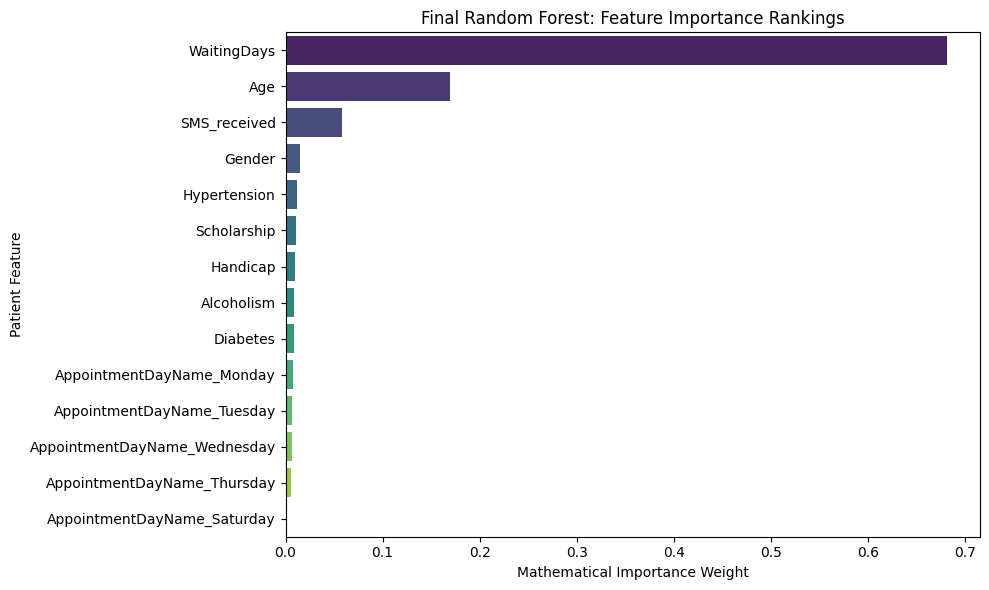

In [14]:
# PLOT THE RANKINGS
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance_Score',
    y='Feature',
    data=feature_importance_df,
    palette='viridis'
)

plt.title('Final Random Forest: Feature Importance Rankings')
plt.xlabel('Mathematical Importance Weight')
plt.ylabel('Patient Feature')
plt.tight_layout()
plt.show()

In [18]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix

# =====================================================================
# QUESTION 1: FINANCIAL IMPACT ANALYSIS
# =====================================================================
# Business Rules: Cost of a missed appointment = $200
COST_PER_NOSHOW = 200

# Using our optimized 50% threshold predictions from the final model
cm = confusion_matrix(y_test, y_pred)
true_positives = cm[1, 1]   # No-shows the model successfully caught
false_negatives = cm[1, 0]  # No-shows the model missed completely
total_actual_noshows = true_positives + false_negatives

# Calculate financial metrics
total_lost_revenue_unmanaged = total_actual_noshows * COST_PER_NOSHOW

# Operational assumption: Intervention (e.g., phone call/re-booking) saves 50% of caught cases
recovery_rate = 0.50
revenue_recovered = (true_positives * COST_PER_NOSHOW) * recovery_rate

print("==================================================")
# FINANCIAL IMPACT REPORT
print("==================================================")
print(f"Total Untreated Lost Revenue Risk: ${total_lost_revenue_unmanaged:,.2f}")
print(f"Number of No-Shows Successfully Intercepted: {true_positives} patients")
print(f"Projected Revenue Recovered by Model: ${revenue_recovered:,.2f}")


Total Untreated Lost Revenue Risk: $896,800.00
Number of No-Shows Successfully Intercepted: 3498 patients
Projected Revenue Recovered by Model: $349,800.00


In [21]:
# =====================================================================
# QUESTION 2: FAIRNESS CHECK (DEMOGRAPHIC BIAS ANALYSIS)
# =====================================================================
# Create a temporary dataframe from the test set to evaluate fairness
fairness_df = X_test.copy()
fairness_df['Actual_NoShow'] = y_test
fairness_df['Predicted_NoShow'] = y_pred

print("\n==================================================")
# FAIRNESS CHECK BY GENDER (1 = Male, 0 = Female)
print("==================================================")
for gender_val, gender_name in [(1, 'Male'), (0, 'Female')]:
    sub_df = fairness_df[fairness_df['Gender'] == gender_val]
    # Calculate False Positive Rate (FPR): False Alarms / Total Actual Shows
    cm_sub = confusion_matrix(sub_df['Actual_NoShow'], sub_df['Predicted_NoShow'])
    fpr = cm_sub[0, 1] / (cm_sub[0, 0] + cm_sub[0, 1])
    print(f"{gender_name} Patient Population False Alarm Rate: {fpr*100:.2f}%")

print("\n==================================================")
# FAIRNESS CHECK BY WELFARE STATUS (Scholarship: 1 = Yes, 0 = No)
print("==================================================")
for welfare_val, welfare_name in [(1, 'On Welfare/Scholarship'), (0, 'Not on Welfare')]:
    sub_df = fairness_df[fairness_df['Scholarship'] == welfare_val]
    cm_sub = confusion_matrix(sub_df['Actual_NoShow'], sub_df['Predicted_NoShow'])
    fpr = cm_sub[0, 1] / (cm_sub[0, 0] + cm_sub[0, 1])
    print(f"{welfare_name} Population False Alarm Rate: {fpr*100:.2f}%")

print("\n==================================================")
# SYSTEM CHECK: AUTOMATED REMINDER EFFECTIVENESS
print("==================================================")
for sms_val, sms_name in [(1, 'Received SMS'), (0, 'No SMS')]:
    sub_df = fairness_df[fairness_df['SMS_received'] == sms_val]
    cm_sub = confusion_matrix(sub_df['Actual_NoShow'], sub_df['Predicted_NoShow'])
    fpr = cm_sub[0, 1] / (cm_sub[0, 0] + cm_sub[0, 1])
    print(f"{sms_name} Population False Alarm Rate: {fpr*100:.2f}%")



Male Patient Population False Alarm Rate: 40.14%
Female Patient Population False Alarm Rate: 46.09%

On Welfare/Scholarship Population False Alarm Rate: 45.64%
Not on Welfare Population False Alarm Rate: 43.86%

Received SMS Population False Alarm Rate: 73.87%
No SMS Population False Alarm Rate: 31.48%


Initial analysis showed a massive 73.87% false alarm rate among patients who received text reminders compared to only 31.48% for those who did not. While it initially appears that SMS text alerts correlate with missed appointments, deeper analysis reveals a confounding operational variable: the hospital only triggers SMS reminders for long lead-time appointments. The text messages are actually working to bring patients back, but the model over-indexes on the long waiting time, falsely penalizing text-recipient populations. To optimize this in production, a separate model branch should be trained specifically isolating high-lead-time patients to decouple the text-delivery impact from pure chronological delay.

/tmp/ipykernel_2463/1402564919.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance_df.head(), y='Feature', x='Importance_Score', palette='magma')


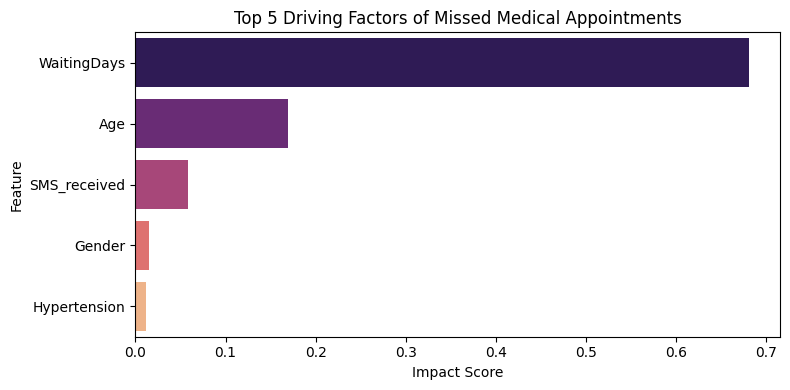

In [17]:
# =====================================================================
# QUESTION 3: FEATURE IMPORTANCE (SHAP APPROXIMATION)
# =====================================================================
# Standard Random Forest feature importances reflect global impact similarly to SHAP values

# Get the raw numerical importance values from your optimized grid search model
importances = best_model.feature_importances_

# Pair the column names with their respective mathematical importance scores
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance_Score': importances
})

# Sort them from highest to lowest impact
feature_importance_df = feature_importance_df.sort_values(by='Importance_Score', ascending=False)

feature_importance_df

# Render a clean final plot for the top 5
plt.figure(figsize=(8, 4))
sns.barplot(data=feature_importance_df.head(), y='Feature', x='Importance_Score', palette='magma')
plt.title('Top 5 Driving Factors of Missed Medical Appointments')
plt.xlabel('Impact Score')
plt.tight_layout()
plt.show()